In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.decomposition import PCA as MiniPCA
from minilearn.classifiers import LogisticRegression as MiniLR

from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

# load saved train and test data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv("../data/test_features.csv")

features_cols = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[features_cols].values
y_train = train_df['emotion'].values

X_test = test_df[features_cols].values
y_test = test_df['emotion'].values

#fix the fearful label mistake
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")


Training set: (1961, 112)
Test set: (491, 112)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


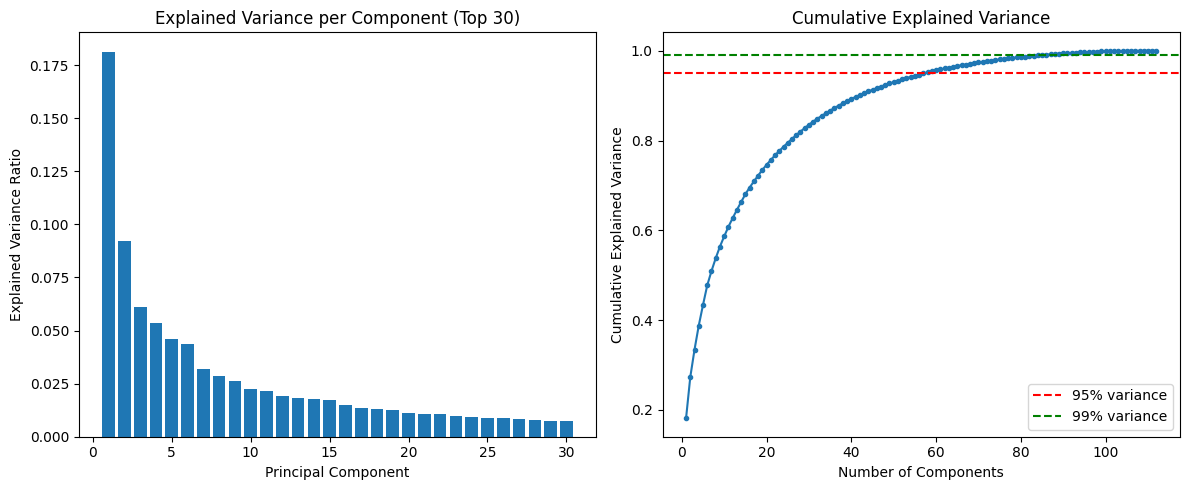

Components needed for 95% variance: 58
Components needed for 99% variance: 85


In [3]:
#fit Minilearn PCA on training data
mini_pca = MiniPCA(n_components=112)
mini_pca.fit(X_train)

cumulative_variance = np.cumsum(mini_pca.explained_variance_ratio_)

plt.figure(figsize=(12,5))
#individual variance
plt.subplot(1,2,1)
plt.bar(range(1,31), mini_pca.explained_variance_ratio_[:30])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per Component (Top 30)")

# cumulative variance
plt.subplot(1,2,2)
plt.plot(range(1,113), cumulative_variance, marker='.')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()

plt.tight_layout()
plt.show()

n_95 = np.argmax(cumulative_variance >= 0.95) +1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")


In [ ]:
#comparing MiniLeanr Vs Sklearn
mini_pca_50 = MiniPCA(n_components=50)
X_train_mini_pca = mini_pca_50.fit_transform(X_train)
X_test_mini_pca = mini_pca_50.transform(X_test)

#SKlearn
sklearn_pca_50 = SklearnPCA(n_components=50, random_state=42)
X_train_sklearn_pca = sklearn_pca_50.fit_transform(X_train)
X_test_sklearn_pca = sklearn_pca_50(X_test)


In [ ]:
# transform data with different numbers of componets
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_components_list = [10, 20, 30, 40, 50, 58, 85, 112]
svm_scores = []
lr_scores = []
rf_scores = []

for n in n_components_list:
    print(f"testing {n} components")

    #apply sklearn PCA
    pca = SklearnPCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    #SVM
    svm = SVC(kernel='rbf', C=10, gamma='scale')
    svm_score = np.mean(cross_val_score(svm, X_train_pca, y_train, cv=skf))
    svm_scores.append(svm_score)

    #logistic Regression
    lr = SklearnLR(max_iter=1000)
    lr_score = np.mean(cross_val_score(lr, X_train_pca, y_train, cv=skf))
    lr_scores.append(lr_score)

    #random forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_score = np.mean(cross_val_score(rf, X_train_pca, y_train, cv=skf))
    rf_scores.append(rf_score)
